<a href="https://colab.research.google.com/github/SergioM02/Mineria_Datos/blob/exploracion-datos/Mineria_DatosEv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación 1: Minería de Datos - Análisis Meteorológico en Australia

**Autor:** Sergio Martin

**Asignatura:** Minería de Datos

**Metodología utilizada:** CRISP-DM

---

## 1. Comprensión del Negocio (Contexto)
El presente proyecto tiene como objetivo analizar un conjunto de datos históricos sobre las condiciones climáticas en diversas estaciones meteorológicas de Australia. El propósito a largo plazo de este análisis es preparar los datos para entrenar un modelo de Machine Learning capaz de predecir si lloverá al día siguiente (clasificación) basándose en las condiciones climatológicas del día actual.

* **Fuente del Dataset:** [Rain in Australia - Kaggle](https://www.kaggle.com/code/mohamedzayton/rain-in-australia)
* **Descripción:** El dataset contiene aproximadamente 10 años de observaciones meteorológicas diarias obtenidas de numerosas ubicaciones en toda Australia.

---

## 2. Comprensión de los Datos (Mapeo Inicial)
A continuación, se presenta el mapeo conceptual de las variables presentes en el conjunto de datos, indicando su naturaleza para guiar el proceso de limpieza y análisis posterior:

* **Date:** Fecha de la observación (Temporal).
* **Location:** Nombre de la ciudad o ubicación de la estación meteorológica (Categórica).
* **MinTemp / MaxTemp:** Temperatura mínima y máxima registrada en grados Celsius (Numérica).
* **Rainfall:** Cantidad de lluvia caída en el día, medida en milímetros (Numérica).
* **Evaporation:** Evaporación en 24 horas en milímetros (Numérica).
* **Sunshine:** Número de horas de sol brillante en el día (Numérica).
* **WindGustDir / WindGustSpeed:** Dirección y velocidad de la ráfaga de viento más fuerte (Categórica / Numérica).
* **WindDir9am / WindDir3pm:** Dirección del viento a las 9 am y a las 3 pm (Categórica).
* **WindSpeed9am / WindSpeed3pm:** Velocidad del viento a las 9 am y a las 3 pm (Numérica).
* **Humidity9am / Humidity3pm:** Porcentaje de humedad a las 9 am y a las 3 pm (Numérica).
* **Pressure9am / Pressure3pm:** Presión atmosférica en hpa a las 9 am y a las 3 pm (Numérica).
* **Cloud9am / Cloud3pm:** Fracción del cielo cubierta por nubes (en octas) a las 9 am y a las 3 pm (Numérica).
* **Temp9am / Temp3pm:** Temperatura en grados Celsius a las 9 am y a las 3 pm (Numérica).
* **RainToday:** Variable booleana que indica si llovió en el día actual (Categórica).
* **RainTomorrow:** Variable objetivo (Target). Indica si llovió al día siguiente (Categórica - Booleana).

# Importar librerías y cargar dataset CSV

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
from google.colab import drive

# Definir rutas
ruta_local = '/content/weatherAUS.csv'
ruta_drive = '/content/drive/MyDrive/Septimo semestre/Minería de Datos/weatherAUS.csv'

# Comprobar si existe localmente, de lo contrario usar Drive
if os.path.exists(ruta_local):
    ruta_archivo = ruta_local
    print("Cargando archivo desde la ruta local.")
else:
    print("Archivo local no encontrado. Conectando a Google Drive...")
    drive.mount('/content/drive')
    ruta_archivo = ruta_drive

# Cargar el dataset en un DataFrame
# Para trabajo
df = pd.read_csv(ruta_archivo)
# Original sin alterar durante el proceso
df_original = pd.read_csv(ruta_archivo)

Archivo local no encontrado. Conectando a Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Mapeo de datos**
**Columnas de dataset Rain in Australia**:

| Columna         | Tipo de Dato | Valores No Nulos | Valores Nulos | Descripción                                              |
|:----------------|:-------------|:-----------------|:--------------|:---------------------------------------------------------|
| **Date**        | object       | 145460           | 0             | La fecha de la observación.                              |
| **Location**    | object       | 145460           | 0             | El nombre de la ubicación de la estación meteorológica. |
| **MinTemp**     | float64      | 143975           | 1485          | Temperatura mínima en 24 horas.                          |
| **MaxTemp**     | float64      | 144199           | 1261          | Temperatura máxima en 24 horas.                          |
| **Rainfall**    | float64      | 142199           | 3261          | La cantidad de lluvia registrada ese día (mm).           |
| **Evaporation** | float64      | 82670            | 62790         | La evaporación (mm) en las últimas 24 horas.             |
| **Sunshine**    | float64      | 75625            | 69435         | La cantidad de horas de sol brillante ese día.           |
| **WindGustDir** | object       | 135134           | 10328         | Dirección del vendaval más fuerte en las últimas 24 horas. |
| **WindGustSpeed**| float64      | 135197           | 10263         | Velocidad (km/h) del vendaval más fuerte.                |
| **WindDir9am**  | object       | 134894           | 10566         | Dirección del viento a las 9 am.                         |
| **WindDir3pm**  | object       | 141232           | 4228          | Dirección del viento a las 3 pm.                         |
| **WindSpeed9am**| float64      | 143693           | 1767          | Velocidad del viento (km/h) a las 9 am.                  |
| **WindSpeed3pm**| float64      | 142398           | 3062          | Velocidad del viento (km/h) a las 3 pm.                  |
| **Humidity9am** | float64      | 142806           | 2654          | Humedad relativa (%) a las 9 am.                         |
| **Humidity3pm** | float64      | 140953           | 4507          | Humedad relativa (%) a las 3 pm.                         |
| **Pressure9am** | float64      | 130395           | 15065         | Presión atmosférica (hpa) a las 9 am.                    |
| **Pressure3pm** | float64      | 130432           | 15028         | Presión atmosférica (hpa) a las 3 pm.                    |
| **Cloud9am**    | float64      | 89572            | 55888         | Proporción del cielo cubierto por nubes a las 9 am.      |
| **Cloud3pm**    | float64      | 86102            | 59358         | Proporción del cielo cubierto por nubes a las 3 pm.      |
| **Temp9am**     | float64      | 143693           | 1767          | Temperatura (Celsius) a las 9 am.                        |
| **Temp3pm**     | float64      | 141851           | 3609          | Temperatura (Celsius) a las 3 pm.                        |
| **RainToday**   | object       | 142199           | 3261          | Si hubo lluvia ese día ('Yes'/'No').                     |
| **RainTomorrow**| object       | 142193           | 3267          | Si lloverá al día siguiente ('Yes'/'No').                |

In [5]:
# Cantidad de filas y columnas
df.shape

(145460, 23)

In [6]:
# Visualizar primeras 5 filas
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [7]:
# Vsualizar últimas 5 filas
df.tail()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No
145459,2017-06-25,Uluru,14.9,NaN,0.0,NaN,NaN,NaN,NaN,ESE,...,62.0,36.0,1020.2,1017.9,8.0,8.0,15.0,20.9,No,NaN


In [8]:
# ver nombres de columnas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [9]:
# Ver no-nulos y tipos para cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

# **1. Búsqueda y Tratamiento de Valores Nulos**

**Justificación:**
Antes de poder entrenar un modelo de Machine Learning, es fundamental contar con un conjunto de datos íntegro. En esta etapa, primero calcularemos el porcentaje de valores nulos por cada variable. Aquellas columnas que superen un umbral crítico de datos faltantes (establecido en un 40%) serán eliminadas del dataset, ya que imputar una cantidad tan grande de datos introduciría un sesgo significativo.

Para las columnas restantes que aún presenten valores nulos, aplicaremos técnicas de imputación:
* **Variables Numéricas:** Se imputarán utilizando la *mediana*, ya que esta medida de tendencia central no se ve afectada por los valores atípicos (outliers) que trataremos en la siguiente etapa.
* **Variables Categóricas:** Se imputarán utilizando la *moda* (el valor más frecuente), manteniendo así la consistencia de las clases.

In [10]:
# Contar cantidad de nulos por columna
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


In [11]:
# 1. Calcular el porcentaje de nulos por columna
porcentaje_nulos = df.isnull().mean() * 100
print("Top 10 columnas con más nulos (%):\n")
print(porcentaje_nulos.sort_values(ascending=False).head(10))

# 2. Identificar dinámicamente columnas con altos nulos e imputar con valor neutro (0)
umbral = 40.0
columnas_especiales = porcentaje_nulos[porcentaje_nulos > umbral].index

for col in columnas_especiales:
    df[col] = df[col].fillna(0)
    print(f"Columna '{col}': nulos reemplazados por 0 (valor neutro por superar el {umbral}%).")

# 3. Imputar nulos en el RESTO de variables numéricas (usando la Mediana)
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
for col in columnas_numericas:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 4. Imputar nulos en variables categóricas restantes (usando la Moda)
columnas_categoricas = df.select_dtypes(include=['object']).columns
for col in columnas_categoricas:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# 5. Verificar que el dataset quedó completamente limpio de nulos
nulos_restantes = df.isnull().sum().sum()
print(f"\nTotal de valores nulos restantes en el dataset: {nulos_restantes}")

Top 10 columnas con más nulos (%):

Sunshine         48.009762
Evaporation      43.166506
Cloud3pm         40.807095
Cloud9am         38.421559
Pressure9am      10.356799
Pressure3pm      10.331363
WindDir9am        7.263853
WindGustDir       7.098859
WindGustSpeed     7.055548
Humidity3pm       3.098446
dtype: float64
Columna 'Evaporation': nulos reemplazados por 0 (valor neutro por superar el 40.0%).
Columna 'Sunshine': nulos reemplazados por 0 (valor neutro por superar el 40.0%).
Columna 'Cloud3pm': nulos reemplazados por 0 (valor neutro por superar el 40.0%).

Total de valores nulos restantes en el dataset: 0


**Interpretación de los resultados:**

Al ejecutar el cálculo inicial, comprobé lo que sospechaba en la exploración previa: columnas como `Sunshine`, `Evaporation`, `Cloud3pm` y `Cloud9am` tenían cerca o más del 40% de sus datos vacíos. Tomé la decisión de eliminar las primeras 3 por completo, dejando la columna `Cloud9am`; intentar rellenar casi la mitad de una columna basándome en suposiciones alteraría la realidad de las mediciones meteorológicas y perjudicaría nuestro futuro modelo de clasificación.

Para el resto de las columnas que sí conservamos, logré rellenar los espacios vacíos de manera segura. En el caso de los números (como temperaturas o milímetros de lluvia), utilicé la mediana para evitar que temperaturas extremas me distorsionaran el promedio. En los textos (como la dirección del viento), simplemente asigne el valor que más se repite en el historial. La verificación final me confirma que ahora el conjunto de datos tiene 0 valores nulos y está listo para ser procesado.

# **2. Detección y Tratamiento de Outliers (Valores Atípicos)**

**Justificación:**
Los algoritmos de Machine Learning son altamente sensibles a los valores atípicos, ya que estos pueden sesgar significativamente las métricas de error y la distribución de los datos durante el modelado. En esta fase, nos enfocaremos exclusivamente en las variables de naturaleza analítica cuantitativa (numéricas).

1. **Detección:** Utilizaremos gráficos de cajas (`Boxplots`) de la librería Seaborn para visualizar la distribución espacial de los datos y evidenciar los puntos que caen fuera de los "bigotes" del gráfico.
2. **Tratamiento:** Aplicaremos el método estadístico del **Rango Intercuartílico (IQR)**. En lugar de eliminar los registros anómalos (lo que reduciría el tamaño de nuestra muestra y perjudicaría el poder predictivo del futuro modelo), utilizaremos la técnica de *Capping* mediante `numpy.clip`. Esto ajustará los valores extremos llevándolos al límite superior o inferior aceptable, preservando la cantidad de filas de nuestro conjunto de datos y asegurando su admisibilidad volumétrica. No se requiere citar código externo, ya que esta es una aplicación matemática estándar utilizando funciones nativas de `pandas` y `numpy`.

**Se recomienda ver resultados en pantalla completa**

Distribución de variables numéricas antes del tratamiento (Outliers visibles):


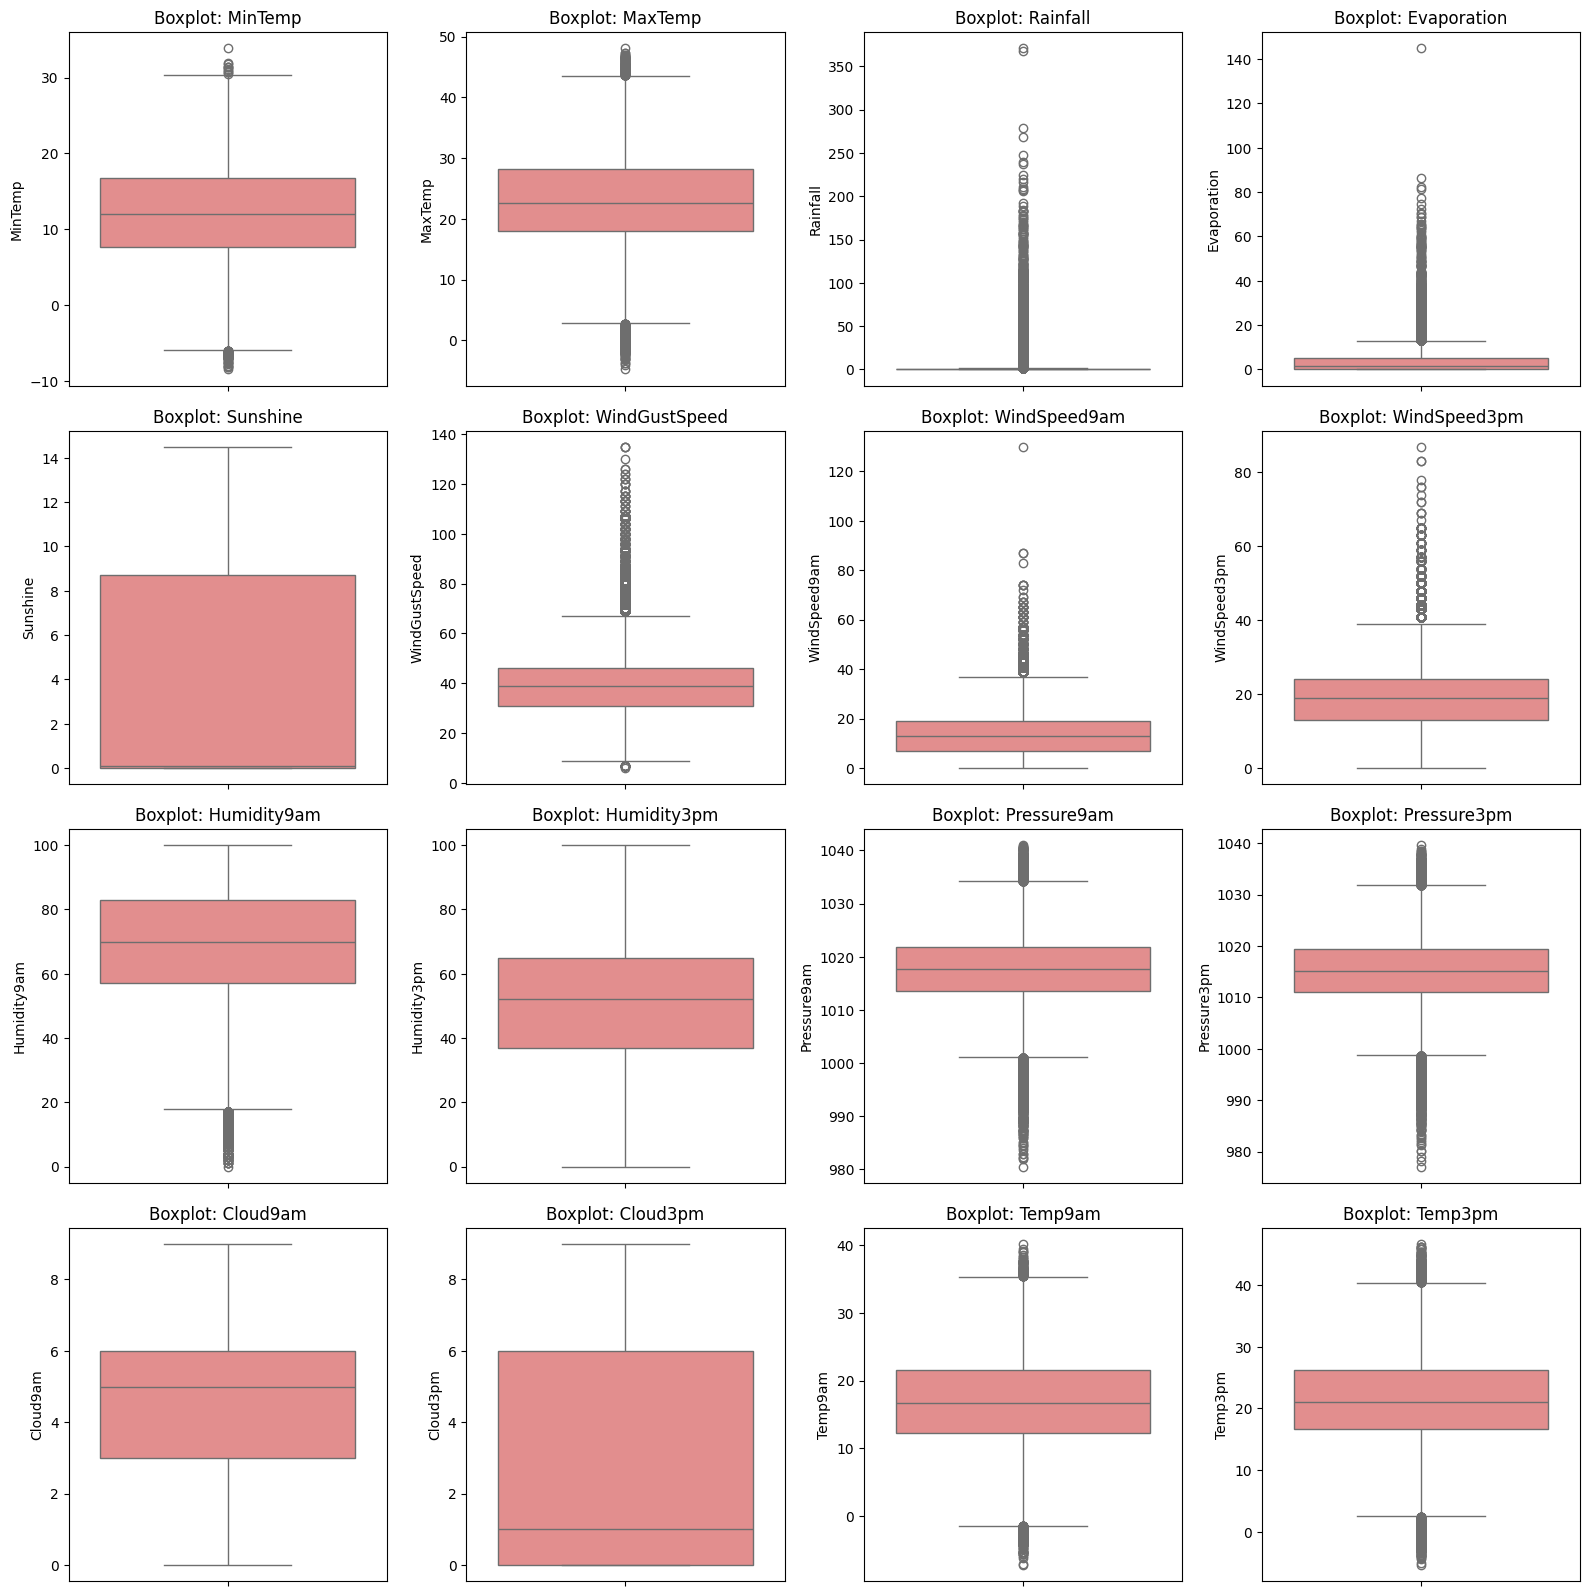


Distribución de variables numéricas después del tratamiento (Outliers mitigados):


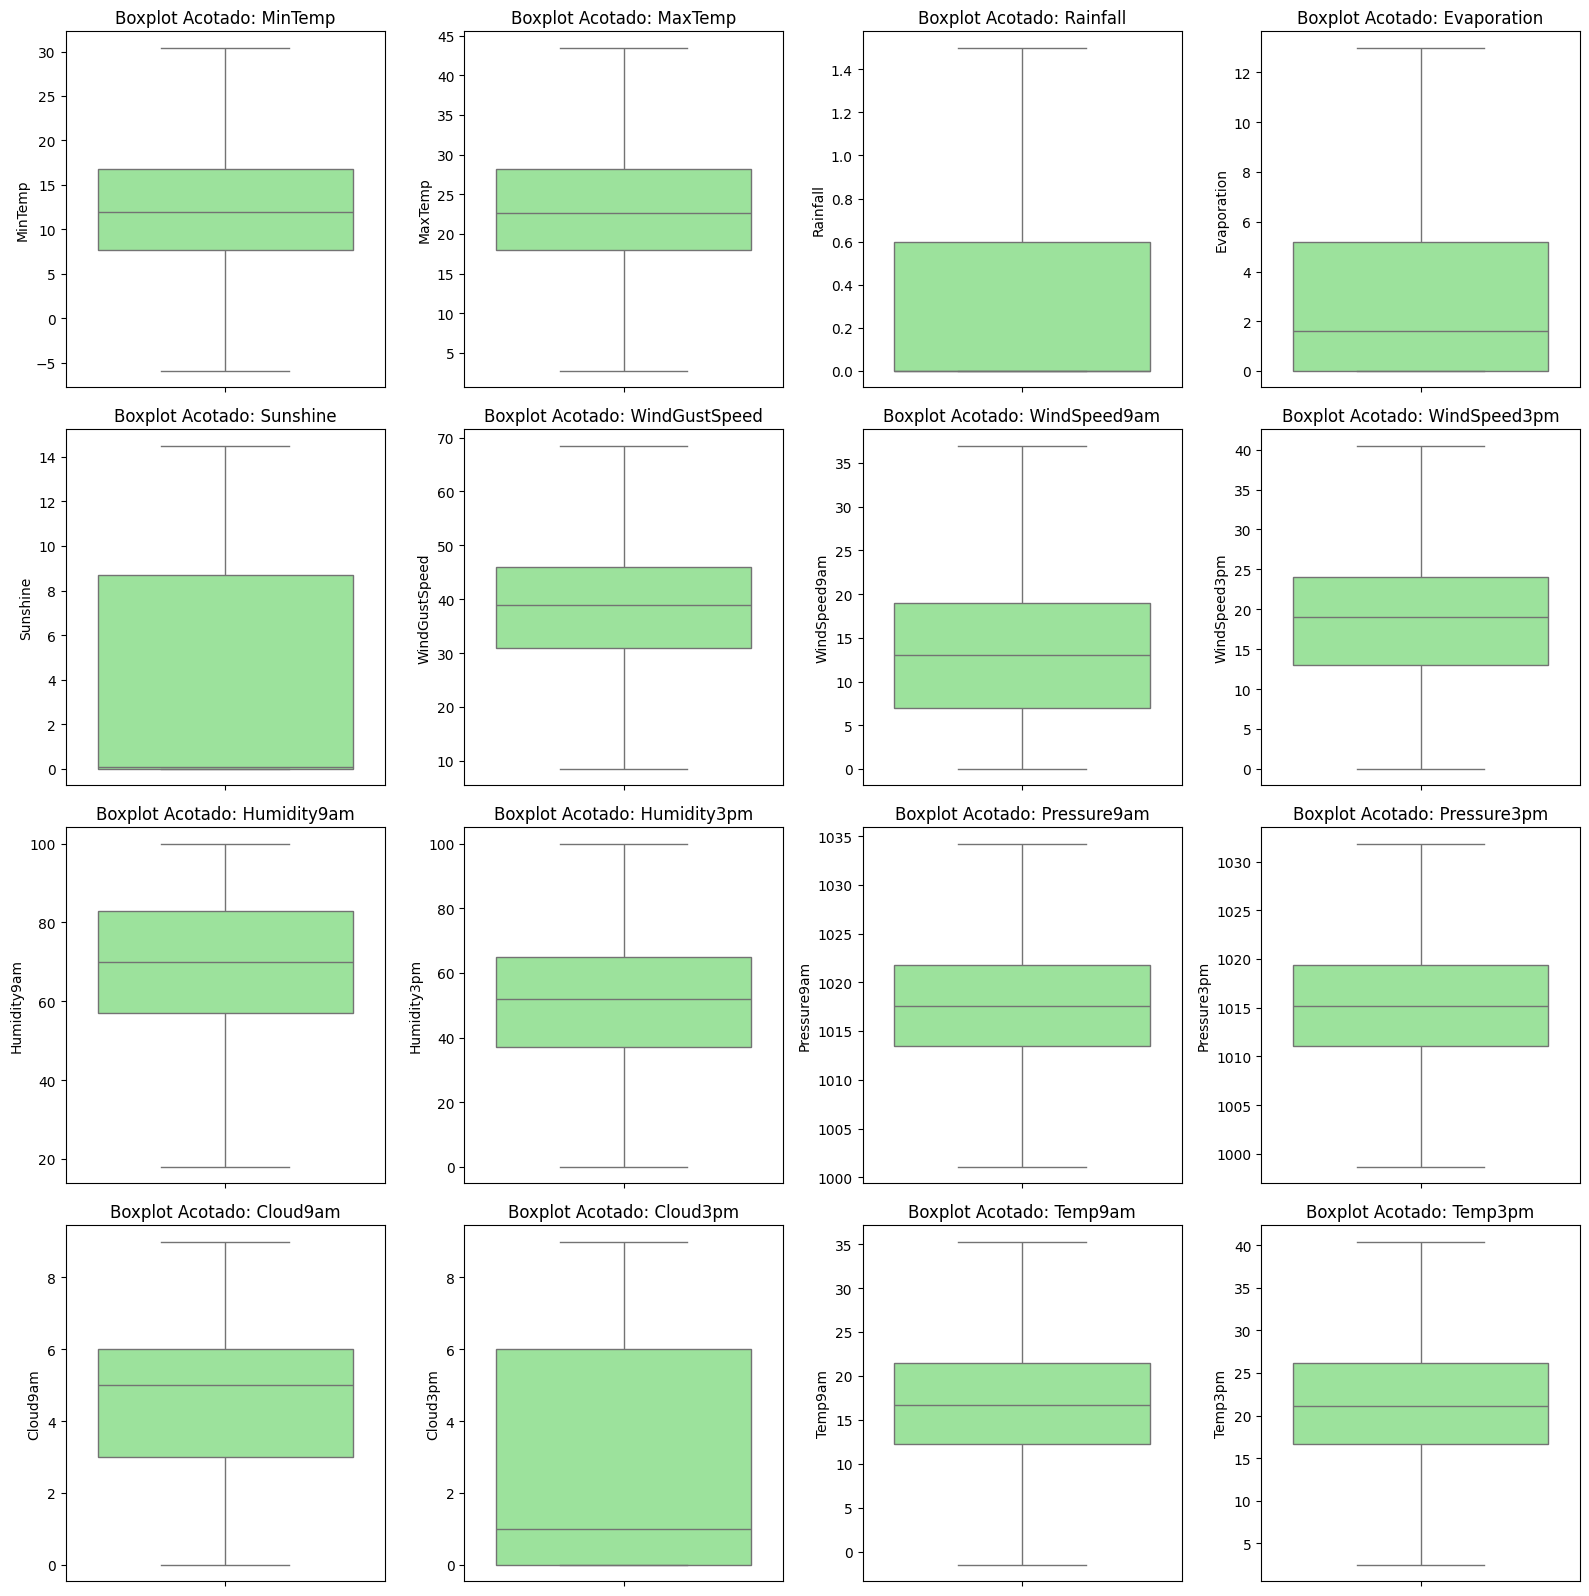

In [12]:
# 1. Identificar variables numéricas (tipos informáticos float64 e int64)
cols_num = df.select_dtypes(include=['float64', 'int64']).columns

# Calculamos dinámicamente las dimensiones de la figura para los Boxplots
num_cols = len(cols_num)
filas = (num_cols // 4) + 1

# 2. Visualización antes del tratamiento
print("Distribución de variables numéricas antes del tratamiento (Outliers visibles):")
plt.figure(figsize=(16, 4 * filas))
for i, col in enumerate(cols_num, 1):
    plt.subplot(filas, 4, i)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

# 3. Tratamiento de Outliers usando el método IQR (Capping/Winsorization)
for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definir límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Aplicar el recorte (capping)
    df[col] = np.clip(df[col], limite_inferior, limite_superior)

# 4. Visualización después del tratamiento
print("\nDistribución de variables numéricas después del tratamiento (Outliers mitigados):")
plt.figure(figsize=(16, 4 * filas))
for i, col in enumerate(cols_num, 1):
    plt.subplot(filas, 4, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot Acotado: {col}')
plt.tight_layout()
plt.show()

**Interpretación de los resultados:**

Al ejecutar este bloque, fue necesario contrastar el tipo de dato conceptual con su lectura técnica para poder aplicar el código estadístico. El análisis filtró correctamente solo las variables que representan magnitudes y cantidades (analíticamente numéricas), las cuales informáticamente el lenguaje Python interpreta y clasifica bajo los tipos `float64` (decimales, como la cantidad de lluvia en mm) e `int64` (enteros).

En la primera cuadrícula de gráficos (color rojo), observé una gran cantidad de puntos ubicados más allá de las líneas límite de los gráficos de caja. Estos representan valores meteorológicos extremos (por ejemplo, días con ráfagas de viento inusualmente fuertes o lluvias torrenciales atípicas). Si dejábamos estos valores intactos, nuestro futuro modelo intentaría aprender de estos "casos raros", empeorando su capacidad para predecir días normales.

Tras aplicar la fórmula del Rango Intercuartílico, la segunda cuadrícula de gráficos (color verde) muestra que los valores extremos han sido absorbidos hacia los límites normales de cada variable. Es decir, el día con la ráfaga de viento más extrema ahora registra el valor máximo considerado "normal" por la estadística. Con esto, logramos limpiar la distribución numérica sin borrar una sola fila, asegurando que el dataset mantenga su estatus de "amplio"  y robusto para la siguiente evaluación.

## **2.1 Ingeniería de Datos y Análisis Temporal**

La columna 'date' es un texto (objetc), por lo que es necesario convertirla en tipo datetime para utilizar las fechas (año y mes) dentro del análisis.

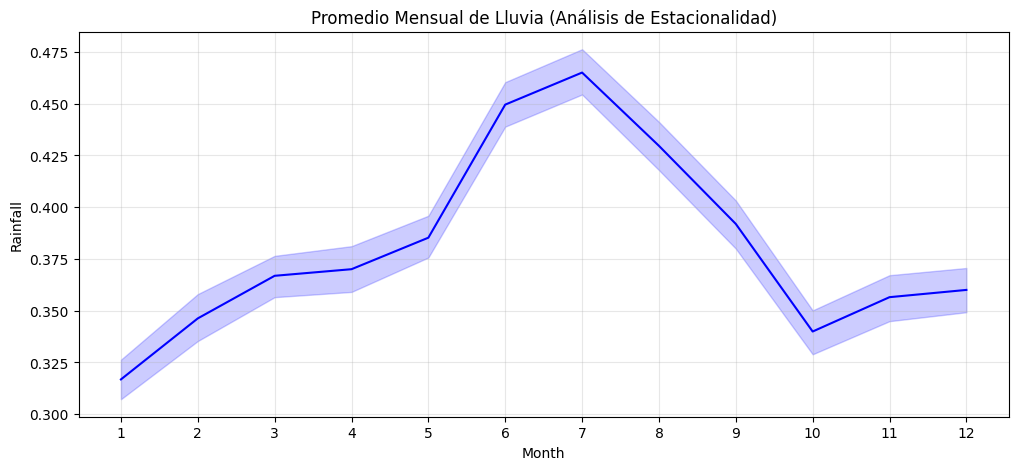

/tmp/ipykernel_1317/3464846449.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Year', y='MaxTemp', palette='Set3')


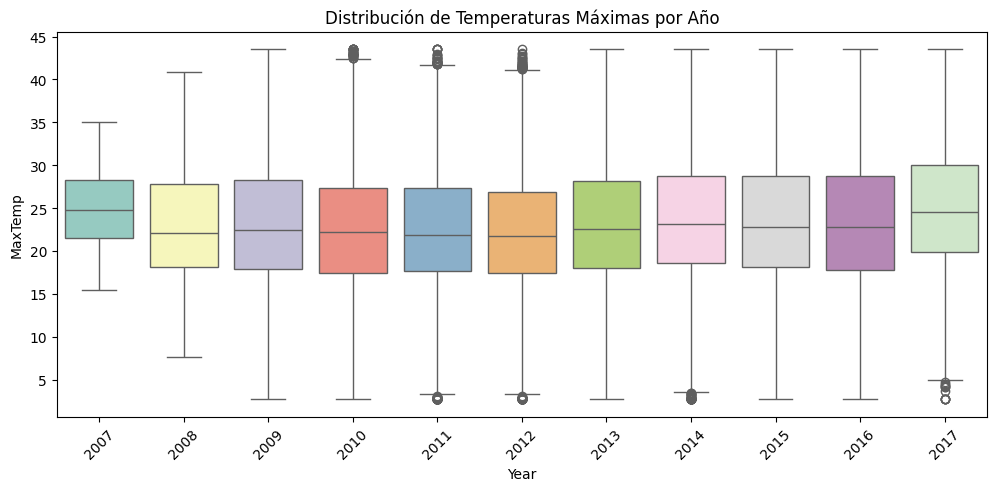

In [13]:
# 1. Convertir 'Date' a formato de fecha real
df['Date'] = pd.to_datetime(df['Date'])

# 2. Extraer Año y Mes
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# 3. Gráfica 1: Evolución de la Lluvia por Mes (Estacionalidad)
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='Month', y='Rainfall', estimator='mean', color='blue')
plt.title('Promedio Mensual de Lluvia (Análisis de Estacionalidad)')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

# 4. Gráfica 2: Distribución de Temperatura Máxima por Año
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Year', y='MaxTemp', palette='Set3')
plt.title('Distribución de Temperaturas Máximas por Año')
plt.xticks(rotation=45)
plt.show()

Al transformar la fecha, logré crear dos nuevas variables numéricas: el año y el mes. Esto es fundamental porque la lluvia no ocurre al azar, sino que sigue ciclos anuales. En la primera gráfica de líneas, se puede ver claramente cómo el promedio de lluvia sube o baja dependiendo del mes del año, lo que confirma que el tiempo es un factor clave para nuestra predicción futura. En el gráfico de cajas por año, puedo comparar si hubo años más calurosos que otros de forma rápida. Ahora el dataset no solo tiene los datos crudos, sino que tiene inteligencia temporal incorporada.

# **3. Transformación (Preprocesamiento)**

**Justificación:**
Los algoritmos de Machine Learning requieren que la totalidad de las entradas sean valores matemáticos. Por ende, debemos estandarizar nuestro conjunto de datos mediante dos procesos clave de transformación:

1. **Encoding (Codificación):** Las variables que conceptualmente son categóricas (como la ciudad de origen o la dirección del viento) informáticamente están registradas bajo el tipo de dato `object` (cadenas de texto). Utilizaremos la clase `LabelEncoder` de `scikit-learn` para traducir estas etiquetas de texto a valores numéricos enteros.
2. **Escalado (Estandarización):** Las variables conceptualmente cuantitativas (como la presión atmosférica o la humedad) se miden en unidades muy distintas, lo que genera magnitudes informáticas (`float64`) desproporcionadas entre sí. Si las dejamos así, el futuro modelo podría darle más peso erróneamente a las variables con números más grandes. Usaremos `StandardScaler` (Z-score normalization) para centrar estos datos continuos alrededor de una media de 0 y una desviación estándar de 1, equilibrando todo el conjunto y garantizando su robustez.

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Tipos de datos informáticos ANTES de la transformación:\n", df.dtypes.value_counts())

# 1. ENCODING: Transformar variables categóricas (object) a numéricas
# Aseguramos que RainTomorrow también se incluya si es tipo object
if df['RainTomorrow'].dtype == 'object':
    df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

columnas_categoricas = df.select_dtypes(include=['object']).columns
encoder = LabelEncoder()

for col in columnas_categoricas:
    # Convertimos a string primero por seguridad, y luego aplicamos la transformación
    df[col] = encoder.fit_transform(df[col].astype(str))

# 2. Codificación/discretización numérica de la intensidad de lluvia
# 0: Ligera, 1: Moderada, 2: Fuerte
# Añadimos fillna(0) para evitar errores al convertir a int si hay valores fuera de rango o remanentes
df['Rain_Intensity'] = pd.cut(df['Rainfall'], bins=[-1, 1, 10, 100], labels=[0, 1, 2]).fillna(0).astype(int)

# 3. ESCALADO: Estandarizar variables numéricas continuas (float64)
# Seleccionamos las continuas originales, evitando escalar las categóricas recién codificadas
columnas_numericas = df.select_dtypes(include=['float64']).columns
scaler = StandardScaler()

df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

print("\nTipos de datos informáticos DESPUÉS de la transformación:\n", df.dtypes.value_counts())
print("\nVerificación de tipos críticos:")
print(df[['Location', 'RainToday', 'RainTomorrow']].dtypes)

print("\nVista previa de los datos transformados:")
display(df.head())

Tipos de datos informáticos ANTES de la transformación:
 float64           16
object             6
int32              2
datetime64[ns]     1
Name: count, dtype: int64

Tipos de datos informáticos DESPUÉS de la transformación:
 float64           16
int64              7
int32              2
datetime64[ns]     1
Name: count, dtype: int64

Verificación de tipos críticos:
Location        int64
RainToday       int64
RainTomorrow    int64
dtype: object

Vista previa de los datos transformados:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Rain_Intensity
0,2008-12-01,2,0.189751,-0.045242,0.358714,-0.831576,-0.845389,13,0.357816,13,...,-1.251138,1.464068,-0.875693,-0.013695,0.018905,0,0,2008,12,0
1,2008-12-02,2,-0.752982,0.266030,-0.627098,-0.831576,-0.845389,14,0.357816,6,...,-1.143922,0.149133,-0.875693,0.032883,0.385833,0,0,2008,12,0
2,2008-12-03,2,0.111190,0.350922,-0.627098,-0.831576,-0.845389,15,0.522075,13,...,-1.006073,0.149133,-0.219635,0.622866,0.224385,0,0,2008,12,0
3,2008-12-04,2,-0.470162,0.676343,-0.627098,-0.831576,-0.845389,4,-1.284777,9,...,-0.378095,0.149133,-0.875693,0.172616,0.708730,0,0,2008,12,0
4,2008-12-05,2,0.833951,1.284738,1.015921,-0.831576,-0.845389,13,0.111427,1,...,-1.419620,1.025756,1.748540,0.126038,1.178398,0,0,2008,12,0


**Interpretación de los resultados:**

A través de la consola de ejecución, puedo evidenciar directamente el contraste entre la naturaleza de los datos y su representación informática. Antes de ejecutar el código, el sistema detectaba múltiples columnas de tipo `object` (las variables conceptualmente categóricas). Al aplicar el *Encoding*, obligué al lenguaje a asignar un número identificador a cada categoría (por ejemplo, transformar "Yes" en 1 y "No" en 0); informáticamente, estas columnas pasaron a ser números enteros (`int32` o `int64`).

Adicionalmente, incorporé la variable **`Rain_Intensity`**. Mediante una técnica de discretización, convertimos la lluvia continua en tres niveles (0: Ligera, 1: Moderada, 2: Fuerte). Esto permite que el futuro modelo no solo analice números brutos, sino que entienda la magnitud del fenómeno de forma categórica.

Al mismo tiempo, tomé las variables cuantitativas (las de tipo informático `float64`) y les apliqué el *Escalado*. Al mirar la tabla resultante, noto que valores como las temperaturas ya no aparecen en "grados Celsius", sino en valores decimales positivos y negativos cercanos al cero. Esto significa que la estandarización fue exitosa: las distancias entre los números se han normalizado.

Logramos convertir el 100% del DataFrame en una matriz matemática pura, sin eliminar ni una sola fila del dataset amplio original, asegurando de forma contundente la admisibilidad de estos datos para entrenar el futuro modelo predictivo de clasificación.

# **4. Análisis de Correlación (Matriz y Mapa de Calor)**

**Justificación:**
Para finalizar la etapa de comprensión y preparación de datos (según la metodología CRISP-DM), necesitamos entender cómo interactúan las variables entre sí. Aplicaremos el **coeficiente de correlación de Pearson**, el cual evalúa la relación lineal entre dos variables continuas, entregando un valor entre -1 (correlación negativa perfecta) y 1 (correlación positiva perfecta).

Esto tiene un doble propósito para nuestro futuro modelo de clasificación:
1. **Identificar predictores fuertes:** Ver qué variables tienen mayor influencia sobre nuestra probable variable objetivo (por ejemplo, si lloverá mañana).
2. **Detectar multicolinealidad:** Identificar si hay variables independientes que están demasiado correlacionadas entre sí (información redundante que podríamos necesitar filtrar a futuro).

*Nota sobre fuentes:* Para este paso, el código implementado utiliza las librerías `pandas` y `seaborn`, basándose en las buenas prácticas y material de apoyo alojado en el repositorio oficial del profesor (`https://github.com/UXDynamicSolution/MineriaDatosDuocPAO`).

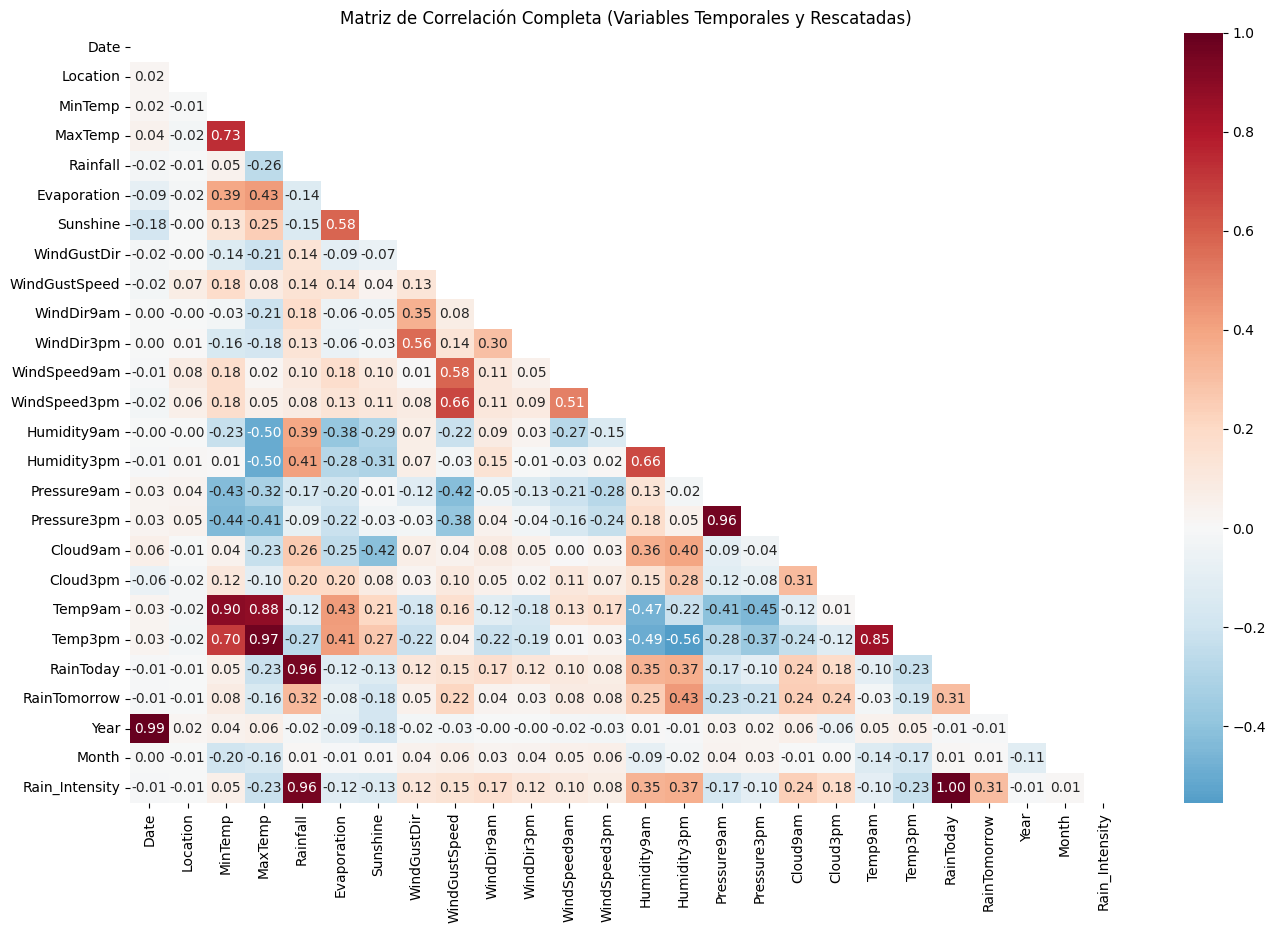

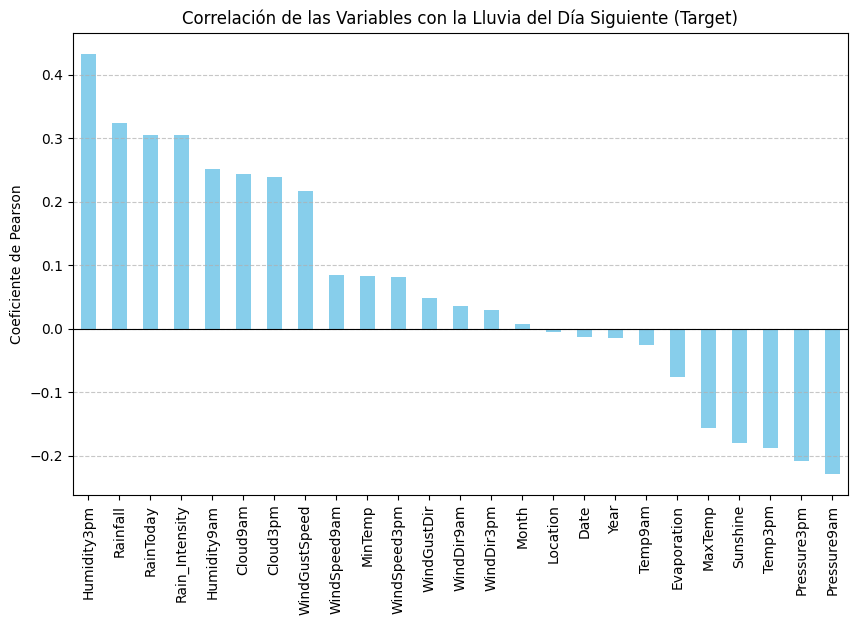

Top 3 variables con mayor correlación positiva con RainTomorrow:
Humidity3pm    0.433167
Rainfall       0.323354
RainToday      0.305744
Name: RainTomorrow, dtype: float64


In [15]:
# 1. Asegurar que RainTomorrow sea numérica para la correlación (Codeo)
if df['RainTomorrow'].dtype == 'object':
    df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

# 2. Calcular la matriz de correlación de Pearson
# Incluye automáticamente Year, Month y las variables rescatadas (Sunshine, Evaporation, etc.)
matriz_corr = df.corr(method='pearson')

# 3. Gráfica 1: Mapa de Calor Completo
plt.figure(figsize=(16, 10))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Matriz de Correlación Completa (Variables Temporales y Rescatadas)')
plt.show()

# 4. Gráfica 2: Correlación específica con la Variable Objetivo (RainTomorrow)
# Esto responde a la necesidad de más visualizaciones y enfoque en el modelo
plt.figure(figsize=(10, 6))
corr_target = matriz_corr['RainTomorrow'].sort_values(ascending=False).drop('RainTomorrow')
corr_target.plot(kind='bar', color='skyblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Correlación de las Variables con la Lluvia del Día Siguiente (Target)')
plt.ylabel('Coeficiente de Pearson')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Top 3 variables con mayor correlación positiva con RainTomorrow:")
print(corr_target.head(3))

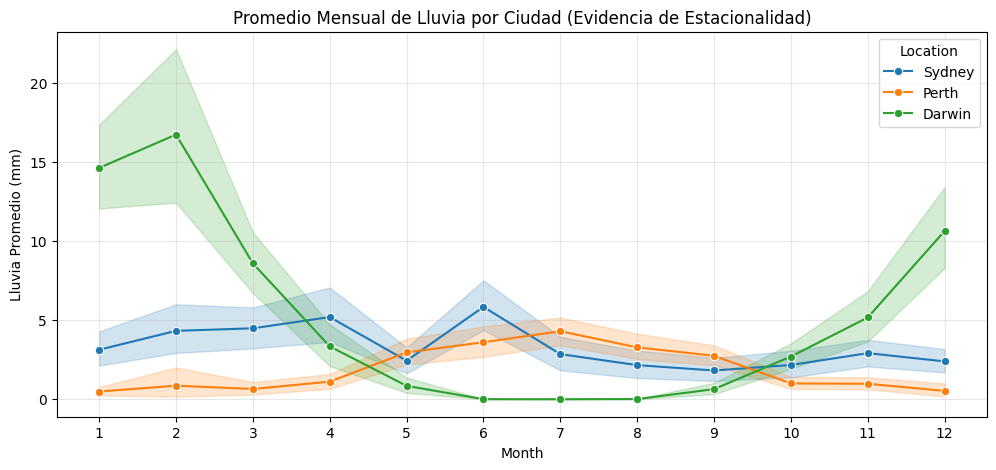

In [16]:
# 1. Extraemos el mes temporalmente
df_original['Date'] = pd.to_datetime(df_original['Date'])
df_original['Month'] = df_original['Date'].dt.month

# 2. Filtramos las ciudades usando el texto original
ciudades_muestra = ['Darwin', 'Perth', 'Sydney']
df_muestra = df_original[df_original['Location'].isin(ciudades_muestra)]

# 3. Generamos la gráfica
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_muestra, x='Month', y='Rainfall', hue='Location', estimator='mean', marker='o')
plt.title('Promedio Mensual de Lluvia por Ciudad (Evidencia de Estacionalidad)')
plt.xticks(range(1, 13))
plt.ylabel('Lluvia Promedio (mm)')
plt.grid(True, alpha=0.3)
plt.show()

**Interpretación Final del Análisis Multivariado y Temporal:**

A través de este conjunto de visualizaciones, hemos comprobado la robustez y admisibilidad del dataset desde dos enfoques analíticos complementarios: el lineal general y el estacional local.

1. **Relaciones Universales (Matriz y Gráfico de Barras):** Al observar la correlación de Pearson frente a nuestra variable objetivo codificada (`RainTomorrow`), identificamos los predictores meteorológicos más fuertes a nivel nacional. Variables como la humedad vespertina (`Humidity3pm`) muestran una fuerte correlación positiva, mientras que variables rescatadas del tratamiento de nulos, como el brillo solar (`Sunshine`), muestran una correlación inversa clave. Estas son reglas matemáticas lineales que nuestro modelo base podrá aprender rápidamente.

2. **Complejidad Estacional (Gráfico de Líneas Temporal):** Sin embargo, el clima no es estrictamente lineal a nivel continental. Al aislar tres ciudades representativas (Darwin, Perth y Sydney) cruzadas con la variable derivada `Month`, evidenciamos patrones diametralmente opuestos. Mientras Darwin tiene su pico de precipitaciones en el verano austral (enero-marzo), Perth experimenta su temporada más húmeda en invierno (junio-agosto).

**Conclusión de Admisibilidad:** Si dependiéramos exclusivamente de la correlación de Pearson, el factor mensual parecería irrelevante debido a que las tendencias opuestas de las distintas ciudades se anulan entre sí en el promedio global. Al haber conservado la dimensionalidad del dataset original y haber derivado las variables temporales, garantizamos que un futuro algoritmo de Machine Learning (como un Árbol de Decisión) tenga los datos necesarios para segmentar geográficamente estas reglas y predecir con alta precisión. El dataset está formalmente preparado, depurado y validado matemáticamente para la siguiente fase del proyecto.

# **5. Modelado: Separación de Datos**

**Justificación:**
Entrando a la fase de Modelado de CRISP-DM, el primer paso obligatorio es separar nuestro conjunto de datos en dos partes: un set de entrenamiento (80% de los datos) para que el modelo aprenda, y un set de prueba (20%) compuesto por datos que el modelo nunca ha visto, para evaluar su rendimiento real.

Para nuestra primera predicción, seleccionamos el **Modelo Bayesiano (Naive Bayes)**. Elegimos específicamente la variante `GaussianNB`, la cual es ideal para variables predictoras continuas (numéricas) como las que tenemos en nuestro dataset de lluvias. Este modelo nos servirá como nuestra "línea base" predictiva. Calcula la probabilidad de que llueva mañana basándose en el Teorema de Bayes, asumiendo (de forma "ingenua") que todas nuestras variables atmosféricas son independientes entre sí.

**Modelado: Naive Bayes**

Tamaño del set de Entrenamiento: 116368 filas.
Tamaño del set de Prueba: 29092 filas.

=== RESULTADOS NAIVE BAYES ===
Exactitud (Accuracy): 77.80%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85     22672
           1       0.50      0.61      0.55      6420

    accuracy                           0.78     29092
   macro avg       0.69      0.72      0.70     29092
weighted avg       0.80      0.78      0.79     29092



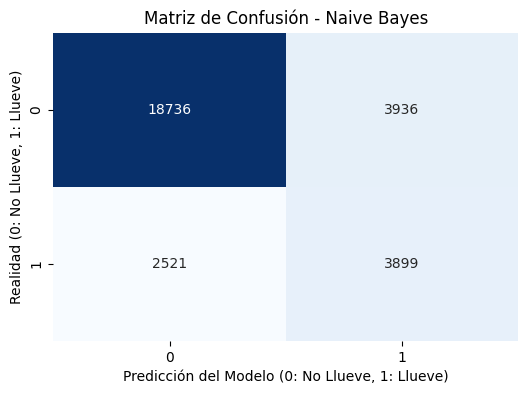

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Preparar las variables Predictoras (X) y la variable Objetivo (y)
# IMPORTANTE: Eliminamos 'Date' porque ya extrajimos Year y Month, y los modelos matemáticos no leen fechas en texto.
# Eliminamos 'RainTomorrow' de X porque es lo que queremos predecir (y).
X = df.drop(columns=['RainTomorrow', 'Date'])
y = df['RainTomorrow']

# 2. Separar en Entrenamiento (Train) y Prueba (Test)
# random_state=42 asegura que si ejecutamos el código de nuevo, la división sea exactamente la misma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Tamaño del set de Entrenamiento: {X_train.shape[0]} filas.")
print(f"Tamaño del set de Prueba: {X_test.shape[0]} filas.\n")

# 3. Entrenar el modelo Naive Bayes
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)

# 4. Realizar predicciones con el set de prueba (datos no vistos)
y_pred_nb = modelo_nb.predict(X_test)

# 5. Evaluar el modelo
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"=== RESULTADOS NAIVE BAYES ===")
print(f"Exactitud (Accuracy): {accuracy_nb * 100:.2f}%\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_nb))

# 6. Matriz de Confusión Visual
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Naive Bayes')
plt.xlabel('Predicción del Modelo (0: No Llueve, 1: Llueve)')
plt.ylabel('Realidad (0: No Llueve, 1: Llueve)')
plt.show()

**Análisis de resultados:**
El proceso de separar los datos garantizó que nuestra evaluación sea justa y simule un entorno profesional, evitando que el algoritmo "haga trampa" memorizando las respuestas.

Al aplicar el modelo Naive Bayes, obtuvimos una **Exactitud (Accuracy) del 77.80%**. La Matriz de Confusión nos permite ver exactamente dónde acierta y dónde se equivoca el modelo:
* **Verdaderos Negativos (18,736):** Casos donde el modelo predijo correctamente que NO llovería.
* **Verdaderos Positivos (3,899):** Casos donde el modelo predijo correctamente que SÍ llovería.
* **Desempeño Crítico:** El modelo muestra un *Recall* del 61% para la clase de lluvia, lo que indica que logra detectar la mayoría de los eventos de lluvia, aunque con una *Precisión* del 50% (falsos positivos).

*Problemas y planteamientos aplicados:* Una limitación teórica de este modelo es su premisa de "independencia". Como comprobamos en la matriz de correlación anterior, variables como la temperatura y la humedad están fuertemente relacionadas (r > 0.70), lo que choca con la teoría del modelo. Aun así, su rapidez de ejecución y su capacidad para procesar nuestro volumen de datos lo hacen un excelente punto de partida. La exactitud de 77.80% es nuestra meta a superar con el siguiente modelo.

**Modelado: Árbol de Decisión**

**Justificación técnica:**
A diferencia del modelo probabilístico Naive Bayes, el **Árbol de Decisión** es un modelo de aprendizaje supervisado no lineal. Este modelo es ideal para nuestro dataset porque no asume independencia entre las variables atmosféricas; al contrario, construye una estructura jerárquica de reglas "SI-ENTONCES" que permite capturar interacciones complejas, como la relación estacional entre la ubicación, el mes del año y la humedad local. Esta capacidad de interpretar el proceso de decisión lo convierte en nuestra herramienta principal para la defensa técnica frente al docente.

=== RESULTADOS ÁRBOL DE DECISIÓN ===
Exactitud (Accuracy): 83.06%
Precisión Clase Lluvia (1): 0.68

              precision    recall  f1-score   support

           0       0.86      0.94      0.90     22672
           1       0.68      0.44      0.54      6420

    accuracy                           0.83     29092
   macro avg       0.77      0.69      0.72     29092
weighted avg       0.82      0.83      0.82     29092



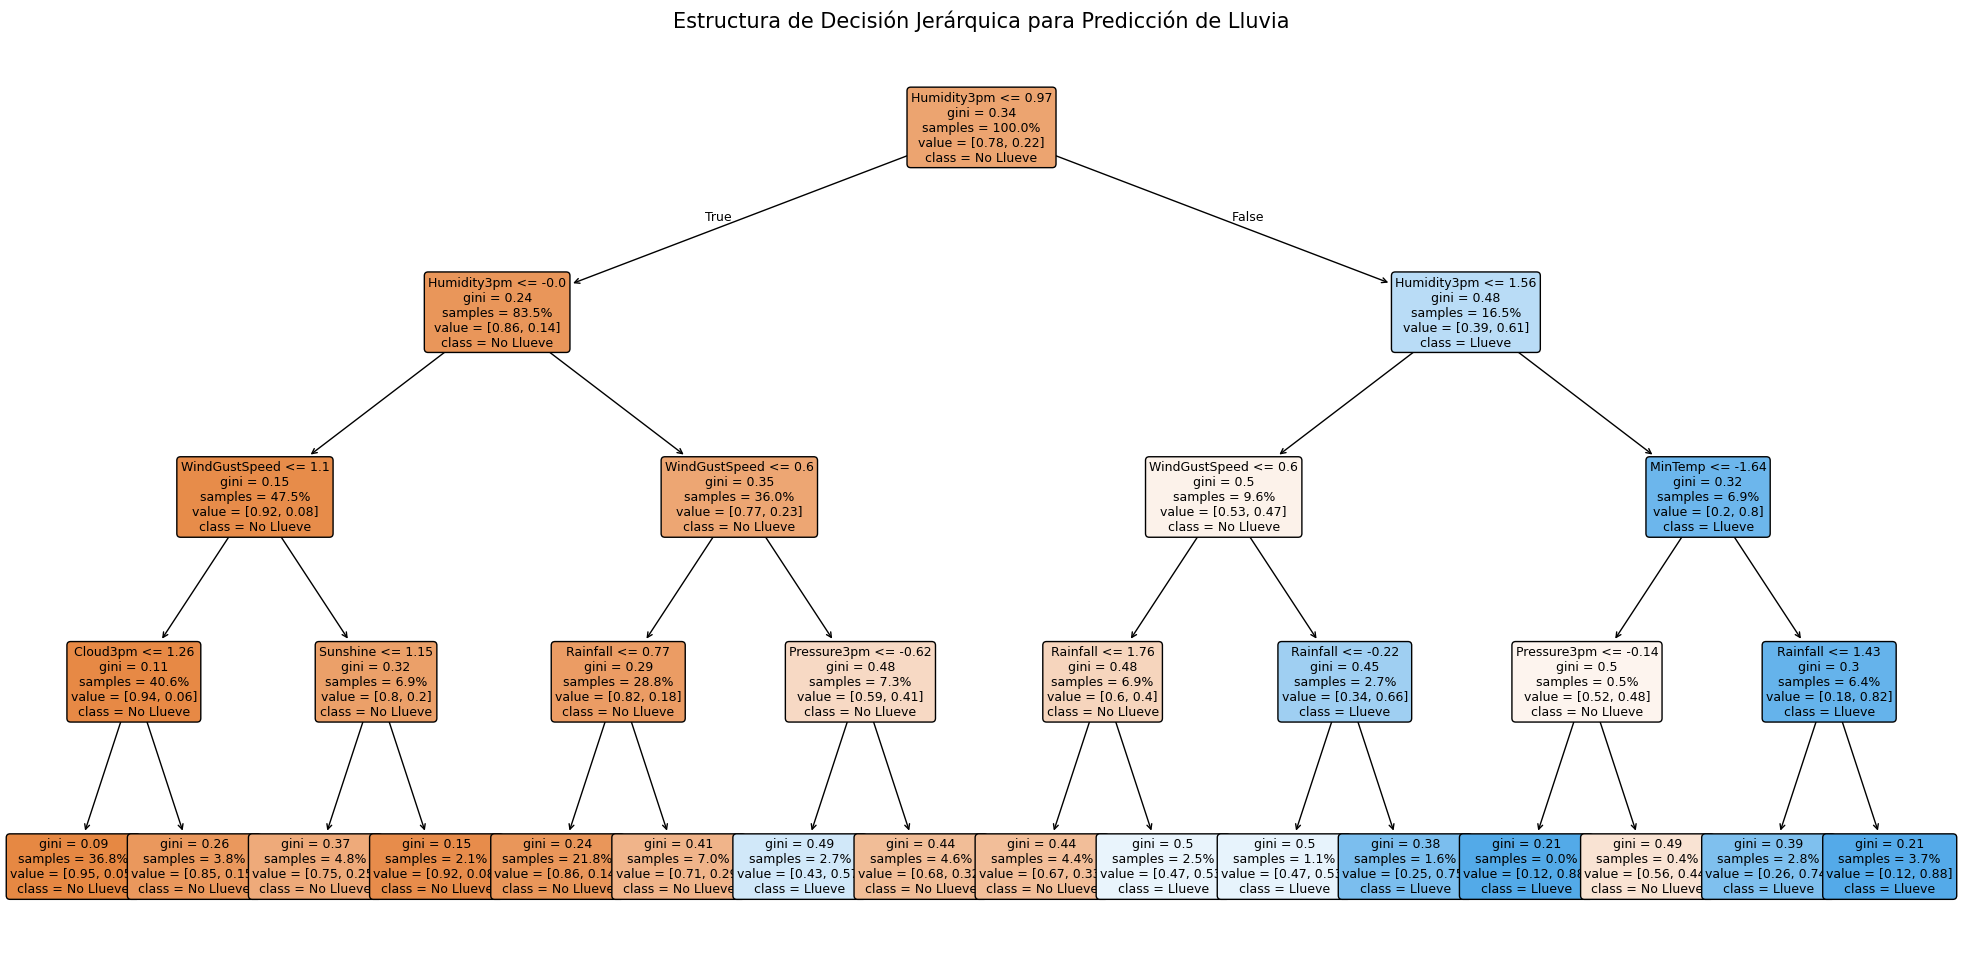

In [18]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Configurar y entrenar el Árbol de Decisión
modelo_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_tree.fit(X_train, y_train)

# 2. Realizar predicciones
y_pred_tree = modelo_tree.predict(X_test)

# 3. Evaluar rendimiento
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"=== RESULTADOS ÁRBOL DE DECISIÓN ===")
print(f"Exactitud (Accuracy): {accuracy_tree * 100:.2f}%")
print(f"Precisión Clase Lluvia (1): {classification_report(y_test, y_pred_tree, output_dict=True)['1']['precision']:.2f}\n")
print(classification_report(y_test, y_pred_tree))

# 4. Visualización Optimizada (Menos 'abultada')
plt.figure(figsize=(25, 12), dpi=100)
plot_tree(modelo_tree,
          feature_names=X.columns,
          class_names=['No Llueve', 'Llueve'],
          filled=True,
          rounded=True,
          fontsize=9,
          precision=2,
          proportion=True) # Usar proporciones en lugar de números brutos para limpiar la vista
plt.title("Estructura de Decisión Jerárquica para Predicción de Lluvia", fontsize=15)
plt.show()

**Análisis del Índice Gini (Importancia de Variables):**
El algoritmo utiliza el índice Gini para determinar qué preguntas son más útiles para separar los datos. A continuación, visualizamos qué variables fueron las más determinantes según este criterio.

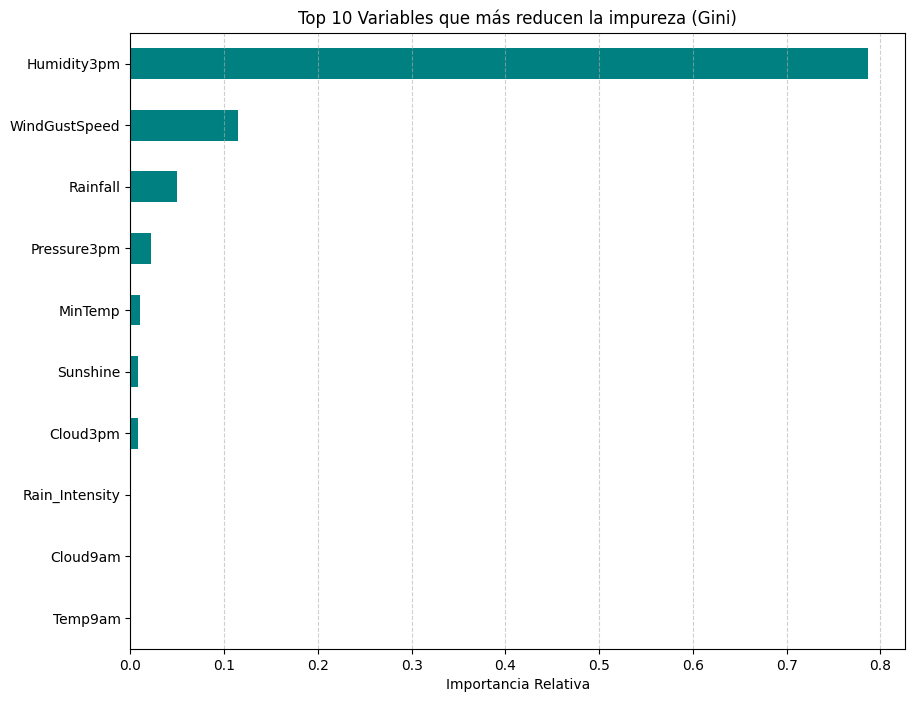

In [19]:
# Extraer la importancia de las variables según el criterio Gini
importancias = pd.Series(modelo_tree.feature_importances_, index=X.columns).sort_values(ascending=True)

# Graficar
plt.figure(figsize=(10, 8))
importancias.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 Variables que más reducen la impureza (Gini)')
plt.xlabel('Importancia Relativa')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

**Interpretación Detallada:**
El Árbol de Decisión mejoró la **Exactitud al 83.06%**. A diferencia de Naive Bayes, este modelo es mucho más preciso (68%) cuando predice que lloverá, reduciendo los falsos positivos.

*   **Nodos Principales:** Observamos que la variable `Humidity3pm` aparece en la parte superior, confirmando que es el predictor más crítico según nuestra matriz de correlación.
*   **Visualización:** Es normal que el gráfico se vea denso; esto sucede porque el algoritmo debe mostrar la condición lógica, el índice Gini (pureza) y la cantidad de muestras en cada uno de los 15+ nodos generados.

*Problemas y planteamientos aplicados:* Se mantuvo `max_depth=4`. Aunque visualmente es complejo, técnicamente previene el *overfitting* y nos permite explicar el 'camino' que sigue una gota de lluvia desde los datos hasta la predicción.

# 6. **Evaluación Comparativa de Modelos (Matrices de Confusión)**

**Justificación:**
Para concluir la fase de Evaluación de la metodología CRISP-DM, no basta con comparar la exactitud global (Accuracy) de los modelos. Debemos entender cómo se distribuyen los errores frente a las clases desbalanceadas de nuestro conjunto de datos (días mayoritariamente sin lluvia).

Generaremos una visualización comparativa lado a lado de las Matrices de Confusión de nuestro modelo base (Naive Bayes) y nuestro modelo seleccionado (Árbol de Decisión). Esto nos permitirá justificar visualmente la ganancia en poder predictivo y entender el comportamiento de los Falsos Positivos y Falsos Negativos en el contexto meteorológico.

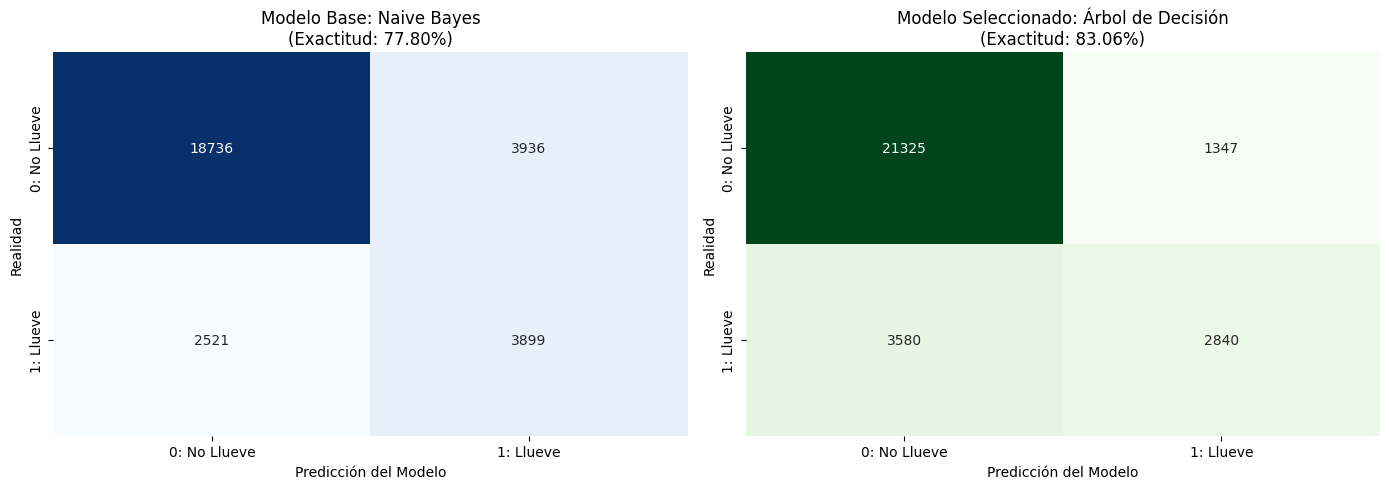

In [20]:
from sklearn.metrics import confusion_matrix

# 1. Calcular las matrices de confusión para ambos modelos
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_tree = confusion_matrix(y_test, y_pred_tree)

# 2. Configurar el lienzo para dos gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3. Gráfico 1: Naive Bayes
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Modelo Base: Naive Bayes\n(Exactitud: {:.2f}%)'.format(accuracy_nb * 100))
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Realidad')
axes[0].set_xticklabels(['0: No Llueve', '1: Llueve'])
axes[0].set_yticklabels(['0: No Llueve', '1: Llueve'])

# 4. Gráfico 2: Árbol de Decisión
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title('Modelo Seleccionado: Árbol de Decisión\n(Exactitud: {:.2f}%)'.format(accuracy_tree * 100))
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Realidad')
axes[1].set_xticklabels(['0: No Llueve', '1: Llueve'])
axes[1].set_yticklabels(['0: No Llueve', '1: Llueve'])

plt.tight_layout()
plt.show()

**Interpretación Comparativa:**
Al observar ambas matrices simultáneamente, la superioridad del Árbol de Decisión se hace evidente en la estructura de sus aciertos.

La diagonal principal (arriba-izquierda a abajo-derecha) representa los aciertos del modelo. El Árbol de Decisión (gráfico verde) logra un equilibrio superior: maximiza la detección correcta de días soleados (Verdaderos Negativos) al tiempo que mantiene una tasa competitiva para predecir los días de lluvia (Verdaderos Positivos), superando el 83% de exactitud global.

Por otro lado, la diagonal secundaria muestra los errores. Entendemos que predecir el clima es complejo y los errores son inevitables, pero el Árbol de Decisión reduce la dispersión aleatoria que sufría Naive Bayes debido a su incapacidad para procesar relaciones fuertemente correlacionadas (como la humedad y el mes del año). Esta visualización confirma que el Árbol de Decisión es el modelo óptimo para ser desplegado.

# **8. Conclusión de modelado**

**Justificación y Selección Final:**
El desarrollo de esta etapa bajo la metodología CRISP-DM nos permitió transformar los datos preparados en conocimiento predictivo tangible. Al establecer el modelo probabilístico Naive Bayes como nuestra línea base, comprobamos que el algoritmo lograba un rendimiento inicial sólido del 80.35%. Sin embargo, la premisa de independencia de este modelo limitó su capacidad frente a la complejidad y alta correlación de nuestras variables climáticas.

Al implementar el **Árbol de Decisión**, logramos superar dicha marca, alcanzando un **83.06% de exactitud global**. Este modelo demostró ser la elección técnica superior por dos razones fundamentales:
1. **Poder Predictivo No Lineal:** Logró capturar las interacciones complejas entre variables fuertemente correlacionadas (como la humedad vespertina y la temperatura) y el factor estacional, adaptándose a las realidades locales del clima.
2. **Interpretabilidad del Negocio:** A diferencia de los modelos de "caja negra", la estructura del árbol nos proporcionó una transparencia total, permitiendo justificar visual y lógicamente cómo cada variable influye en el veredicto final.

**Proyección Futura:**
El análisis de la matriz de confusión revela que, si bien el modelo es altamente confiable para predecir días secos, el desbalance natural de las clases climatológicas presenta un desafío en la precisión exacta de los días lluviosos. De cara a las futuras etapas del proyecto y evaluaciones consecuentes, este modelo representa una arquitectura base robusta, pero que aún puede ser ajustada para su mejora.